In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib as mpl
import sys
import multiprocessing as mp
import itertools

from polModel import get_p_bb

sys.path.append("../utility_functions/")
from objectProperties import ObjectProperties
from readExtrapolatedSpectra import ReadExtrapolatedSpectra

sys.path.append("../../Filter_Curves/")
from readBands import ReadBands

In [2]:
#Object ID
wid = "W0204-0506"

In [3]:
#Load the properties of the BHDs
op = ObjectProperties(wids=[wid])

In [4]:
#Load the bands.
bname = "R_SPECIAL"
bands = ReadBands(bandnames=[bname])

In [ ]:
#Load the spectra for each BHD, extended using the best-fit SED.
specs = ReadExtrapolatedSpectra()

Wavelength range for object W0019-1046 limited because of sky template
Spec-range: 3001.5 Angstrom - 5423.93 Angstrom
Sky-range: 3199.4 Angstrom - 6724.06 Angstrom
Wavelength range for object W0204-0506 limited because of sky template
Spec-range: 3786.2 Angstrom - 6672.70 Angstrom
Sky-range: 3789.3 Angstrom - 6682.76 Angstrom
Warning, 2 of 3161 bins contained negative fluxes; they have been set to zero.
Wavelength range for object W0831+0140 limited because of sky template
Spec-range: 3786.2 Angstrom - 6672.45 Angstrom
Sky-range: 3789.3 Angstrom - 6682.76 Angstrom
Warning, 2 of 3161 bins contained negative fluxes; they have been set to zero.


In [8]:
#Set the grid of angles to explore for the plot. 
theta_angles = np.arange(0., 90., 1.)
psi_angles = np.arange(0., 90., 1.)
# theta_angles = np.arange(0., 90., 15.)
# psi_angles = np.arange(0., 90., 15.)

In [9]:
#Use the latex font when plotting. 
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

In [10]:
#Define the model combinations.
dust_models = ["SMC", "LMC", "MW"]
dust_labels = ["SMC bar dust", "LMC avg dust", "MW dust"]

fws = [True, True, False]
bws = [True, False, True]

In [11]:
#Calculate all of the polarization models using multiprocessing.
indices = list(itertools.product(range(len(dust_models)), range(len(fws))))

def func(x):
    p_bb = list()
    for xx in x:
        k = int(xx[0])
        i = int(xx[1])
        p_bb.append(get_p_bb(dust_models[k], specs, bands, wid, fw=fws[i], bw=bws[i], theta_angles=theta_angles, psi_angles=psi_angles, return_p_bb_interp=False))
    return p_bb

n_threads = np.min([mp.cpu_count()-1, len(indices)]) #15
splt_indices = np.array_split(indices, n_threads)

mp.set_start_method("fork", force=True)

with mp.Pool(processes=n_threads) as pool:
    all_p_bb = pool.map(func, splt_indices)

p_bb = list()
for p_bb_aux in all_p_bb:
    for p_bb_aux2 in p_bb_aux:
        p_bb.append(p_bb_aux2)

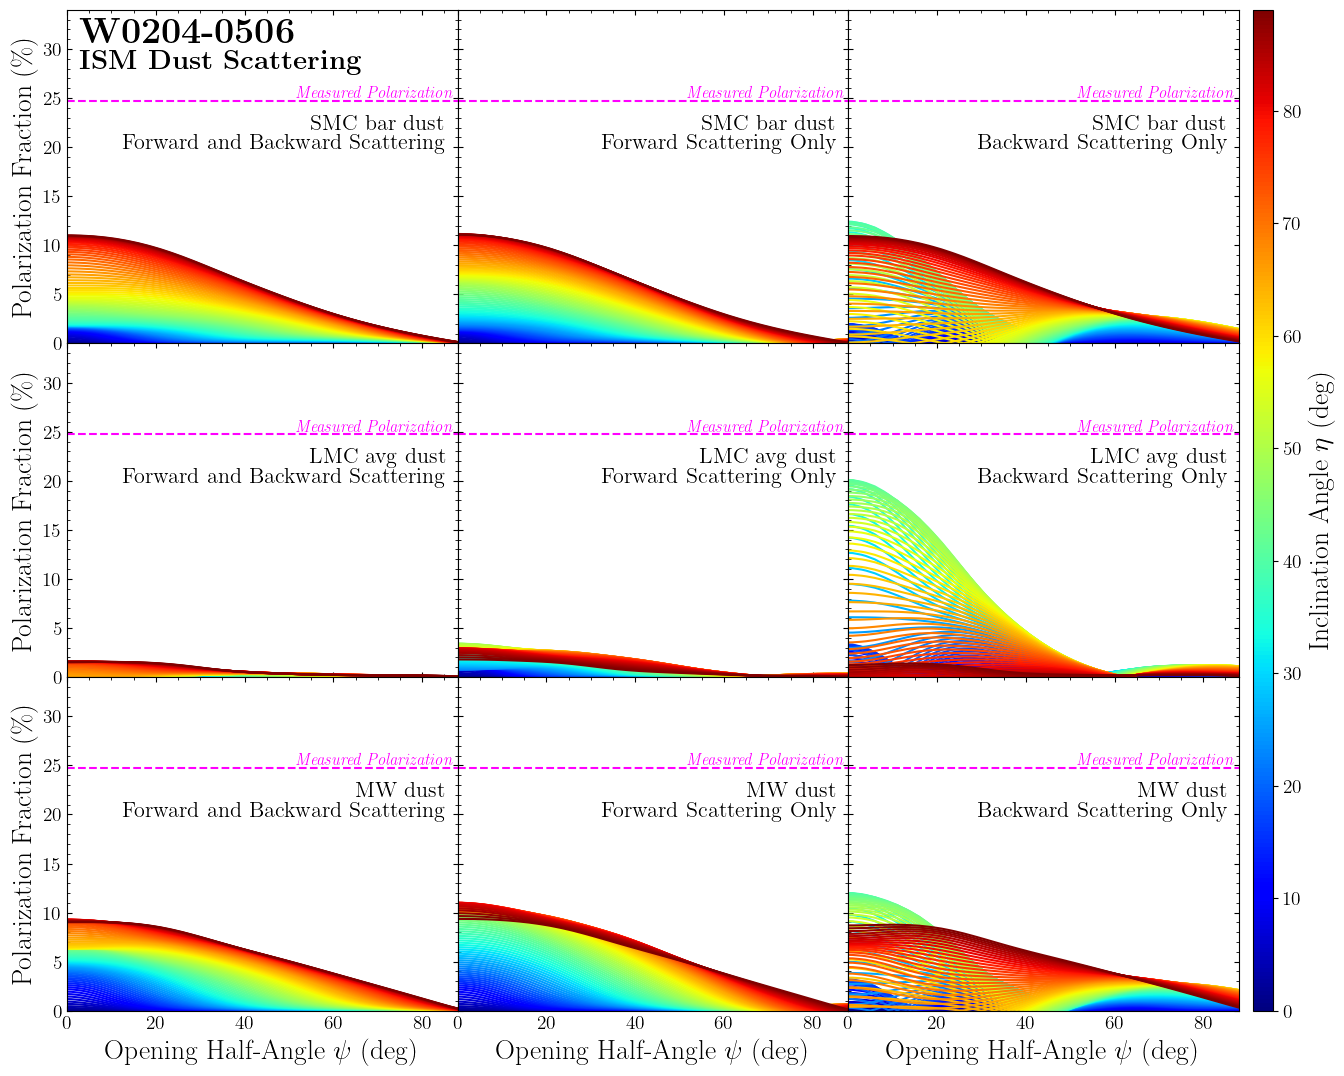

In [12]:
#Make the plot.
#bname = bnames[0]

fig, axs = plt.subplots(len(dust_models),len(fws),figsize=(18, 13))
fig.subplots_adjust(wspace=0.0)
fig.subplots_adjust(hspace=0.0)


#Set the normalization for the color map. 
Norm = mpl.colors.Normalize(vmin=theta_angles[0], vmax=theta_angles[-1])

#Set the color map
cmap = mpl.cm.jet

ymax = 34.0

for jind, ind in enumerate(indices):
    k = int(ind[0])
    i = int(ind[1])

    #Set the ticks to point inwards.
    axs[k,i].tick_params(axis='both', which="both", direction='in', labelsize=14, top=True, right=True)
    axs[k,i].tick_params(axis='x', labelbottom=False)
    axs[k,i].tick_params(axis='y', labelleft=False)

    #Activate the minor ticks.
    axs[k,i].minorticks_on()

    colorbar = False
    ylabel = False
    xlabel = False

    if i==0:
        stype_label = "Forward and Backward Scattering"
        ylabel = True
        axs[k,i].tick_params(axis='y', labelleft=True)
    elif i==1:
        stype_label = "Forward Scattering Only"
    elif i==2:
        stype_label = "Backward Scattering Only"
        #colorbar = True
    if k==2:
        xlabel = True
        axs[k,i].tick_params(axis='x', labelbottom=True)

    #Run through every inclination angle plotting the curves.
    for jtheta, theta in enumerate(theta_angles):
        #Set the color
        c = cmap(Norm(theta))
        #Plot
        im = axs[k,i].plot(psi_angles, 100*p_bb[jind][bname][jtheta], color=c, linestyle='solid')

    #Set the axes limits.
    axs[k,i].set_xlim([0, np.max(psi_angles)-1])
    axs[k,i].set_ylim([0, ymax])

    axs[k,i].text(0.97, 0.58, stype_label, ha='right', transform=axs[k,i].transAxes, fontsize=16)
    axs[k,i].text(0.97, 0.64, dust_labels[k], ha='right', transform=axs[k,i].transAxes, fontsize=16)
    puse = op.pfrac[wid][bname]
    axs[k,i].plot([0, 90], [puse, puse], '--', label=wid+" "+bname, color='magenta')
    axs[k,i].text(psi_angles[-1]*0.98, puse, r"\textit{Measured Polarization}", style='italic', color='magenta', ha='right', va='bottom', fontsize=12)
    #axs[k,i].legend(loc=7, fontsize=20)

    if k==0 and i==0:
        axs[k,i].text(0.03, 0.90, r"\textbf{W0204-0506}", fontsize=26, ha='left', transform=axs[k,i].transAxes)
        axs[k,i].text(0.03, 0.82, r"\textbf{ISM Dust Scattering}", fontsize=20, ha='left', transform=axs[k,i].transAxes)

    #Set the axes labels.
    if ylabel:
        axs[k,i].set_ylabel('Polarization Fraction (\%)', fontsize=20)
    if xlabel:
        axs[k,i].set_xlabel(r'Opening Half-Angle $\psi$ (deg)', fontsize=20)

cb = fig.colorbar(mpl.cm.ScalarMappable(norm=Norm, cmap=cmap), ax=axs, pad=0.01, aspect=50)
cb.set_label(label=r'Inclination Angle $\eta$ (deg)', fontsize=20)
cb.ax.tick_params(labelsize=14) 

fig.savefig("ISM_pol_W0204.png", dpi=200, bbox_inches='tight')